<a href="https://colab.research.google.com/github/dgonzales1222/pml_exercises/blob/main/assignment_02/pml_assignment_02_dgonzales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Practical Machine Learning**
## Assignment 02
Danilo III O. Gonzales (29225) <br>
Master's in Green Data Science


### Problem Overview
The goal is to **predict** `Depth_to_Groundwater_P25` (DP25) for a target month **t** using observations from the two preceding months (**t-1** and **t-2**).

In [1]:
# Import Necessary Python Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    KFold,
    TimeSeriesSplit,
    cross_val_score,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
# @title Loading Data
# @markdown **Prompt**: How to csv data in Google Colab?

# Try loading the csv if its uploaded
try:
    df = pd.read_csv("petrignanos.csv")

# If not loaded, create an upload file button to import the csv file from local.
except FileNotFoundError:
    from google.colab import files
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename)

print(f"Shape: {df.shape}")
df.head()

Shape: (4199, 7)


,Date,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano
0,1/1/2009,0.0,-31.14,5.2,4.9,-24530.688,2.4
1,2/1/2009,0.0,-31.11,2.3,2.5,-28785.888,2.5
2,3/1/2009,0.0,-31.07,4.4,3.9,-25766.208,2.4
3,4/1/2009,0.0,-31.05,0.8,0.8,-27919.296,2.4
4,5/1/2009,0.0,-31.01,-1.9,-2.1,-29854.656,2.3


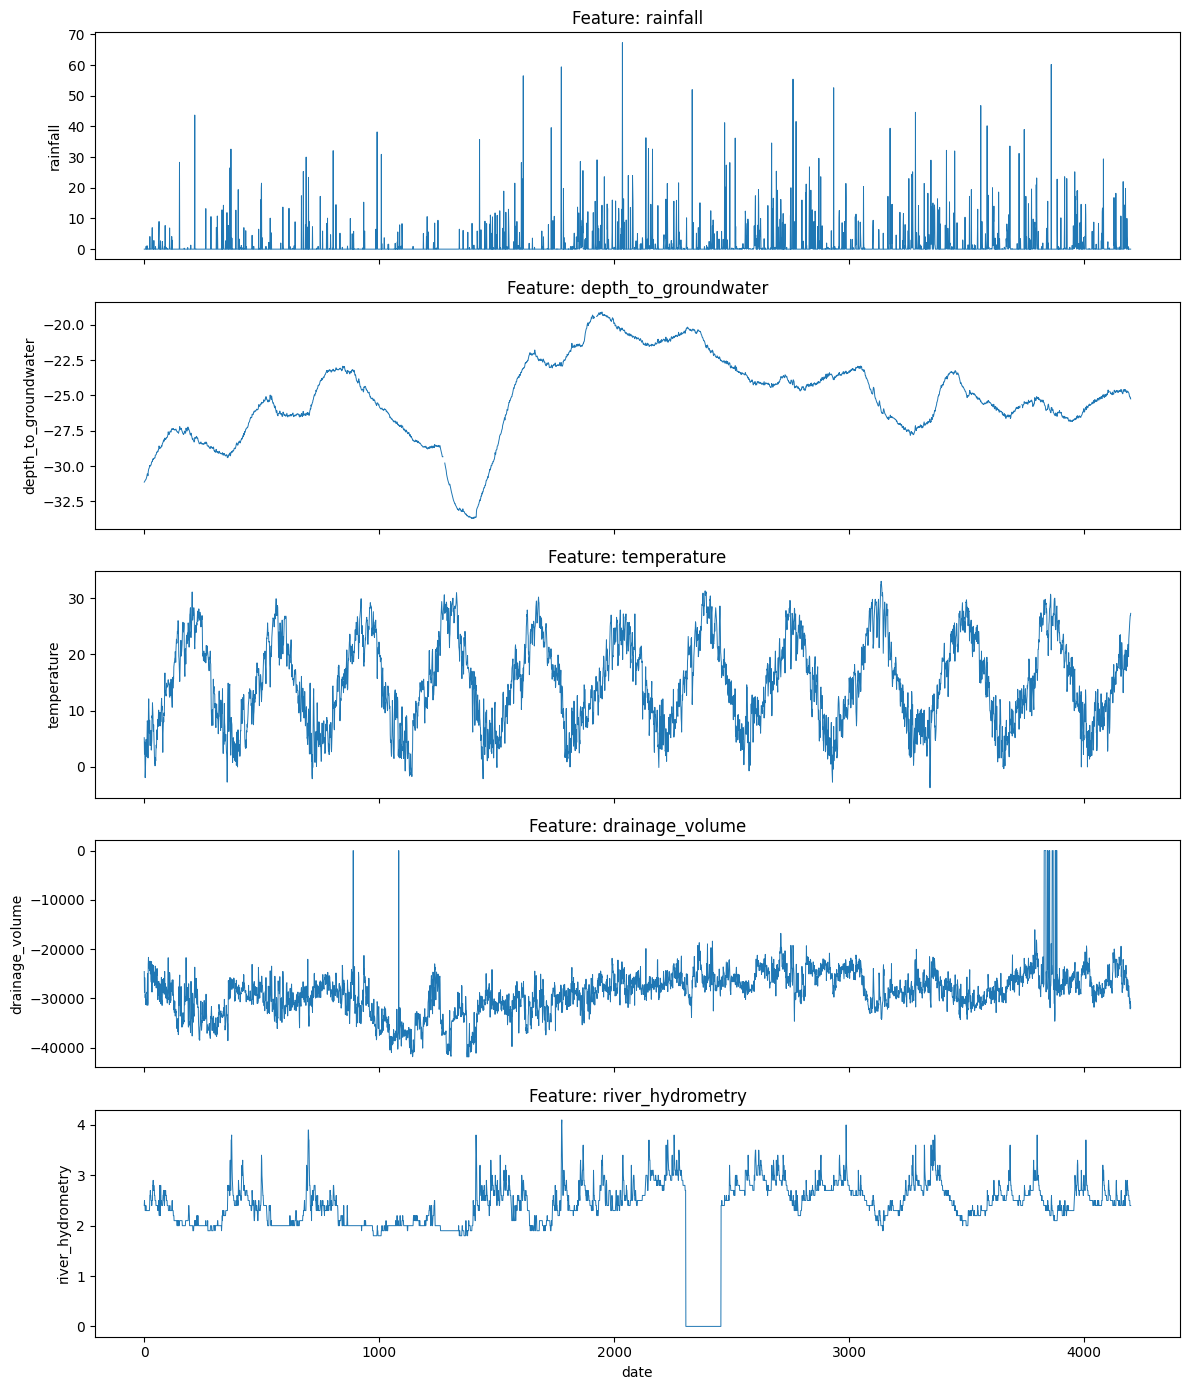

In [3]:
# Overview of Raw Time-Series Data
df_plot = df.copy()

# Short, readable labels for each raw column
plot_map = {
    "Rainfall_Bastia_Umbra":               "rainfall",
    "Depth_to_Groundwater_P25":            "depth_to_groundwater",
    "Temperature_Bastia_Umbra":            "temperature",
    "Volume_C10_Petrignano":               "drainage_volume",
    "Hydrometry_Fiume_Chiascio_Petrignano":"river_hydrometry",
}

fig, axes = plt.subplots(len(plot_map), 1, figsize=(12, 14), sharex=True)
for ax, (col, label) in zip(axes, plot_map.items()):
    ax.plot(df_plot.index, df_plot[col], linewidth=0.7)
    ax.set_title(f"Feature: {label}")
    ax.set_ylabel(label)
axes[-1].set_xlabel("date")

plt.tight_layout()
plt.show()

# 0. Organize data; deal with missing values; determine X,y sorted chronologically; (optional) add seasonality variable

In [4]:
# Parse date and sort
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.sort_values("Date").reset_index(drop=True)

df.head(10)

,Date,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano
0,2009-01-01,0.0,-31.14,5.2,4.9,-24530.688,2.4
1,2009-01-02,0.0,-31.11,2.3,2.5,-28785.888,2.5
2,2009-01-03,0.0,-31.07,4.4,3.9,-25766.208,2.4
3,2009-01-04,0.0,-31.05,0.8,0.8,-27919.296,2.4
4,2009-01-05,0.0,-31.01,-1.9,-2.1,-29854.656,2.3
5,2009-01-06,0.0,-31.00,-0.7,-0.7,-29124.576,2.3
6,2009-01-07,0.0,-30.96,1.5,-0.3,-31173.120,2.3
7,2009-01-08,0.0,-30.94,4.3,6.6,-30232.224,2.4
8,2009-01-09,0.9,-30.93,4.9,4.8,-30597.696,2.3
9,2009-01-10,0.0,-30.87,1.9,4.2,-31337.280,2.3


In [5]:
# Inspect data
print("Data types:\n")
print(df.dtypes)
print("\nMissing values per column:\n")
print(df.isnull().sum())
print("\nBasic statistics:\n")
df.describe()

Data types:

Date                                    datetime64[ns]
Rainfall_Bastia_Umbra                          float64
Depth_to_Groundwater_P25                       float64
Temperature_Bastia_Umbra                       float64
Temperature_Petrignano                         float64
Volume_C10_Petrignano                          float64
Hydrometry_Fiume_Chiascio_Petrignano           float64
dtype: object

Missing values per column:

Date                                     0
Rainfall_Bastia_Umbra                    0
Depth_to_Groundwater_P25                27
Temperature_Bastia_Umbra                 0
Temperature_Petrignano                   0
Volume_C10_Petrignano                    1
Hydrometry_Fiume_Chiascio_Petrignano     0
dtype: int64

Basic statistics:



,Date,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano
count,4199,4199.000000,4172.000000,4199.000000,4199.000000,4198.000000,4199.000000
mean,2014-10-01 00:00:00,1.556633,-25.182534,15.030293,13.739081,-28669.156619,2.372517
min,2009-01-01 00:00:00,0.000000,-33.710000,-3.700000,-4.200000,-41890.176000,0.000000
25%,2011-11-16 12:00:00,0.000000,-26.860000,8.800000,7.700000,-31082.832000,2.100000
50%,2014-10-01 00:00:00,0.000000,-25.170000,14.700000,13.500000,-28389.744000,2.400000
75%,2017-08-15 12:00:00,0.100000,-23.270000,21.400000,20.000000,-26042.904000,2.700000
max,2020-06-30 00:00:00,67.300000,-19.100000,33.000000,31.100000,0.000000,4.100000
std,NaN,5.217923,2.945074,7.794871,7.701369,4570.686434,0.589088


Based on the data inspection, there are $28$ missing data where $27$ are in `Depth_to_Groundwater_P25` and the remaining one is from `Volume_C10_Petrignano`. In our previous exercises, what we usually do is to drop data rows with missing data. However, in time-series prediction, this is not valid, since the system heavily depends on historical data.

To address this issue, we will perform **imputation** which is the process of replacing missing values with estimated ones so the dataset is complete and usable for modeling. Noor et al. (2014) compared linear, quadratic, and cubic interpolation on hourly PM₁₀ data with a similar share of missing values (≈2.1%) and found all three produced nearly identical fits (R² ≈ 0.98). Given this, we try and use **linear interpolation** which is the simplest of the three and well-suited to bridging short gaps without introducing oscillations.

In [6]:
# Imputation via Linear Interpolation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols] = df[numeric_cols].interpolate(method="linear",
                                                limit_direction="both")

# Check if there are still missing data
print(f"Missing values after imputation: {df[numeric_cols].isnull().sum().sum()}")

Missing values after imputation: 0


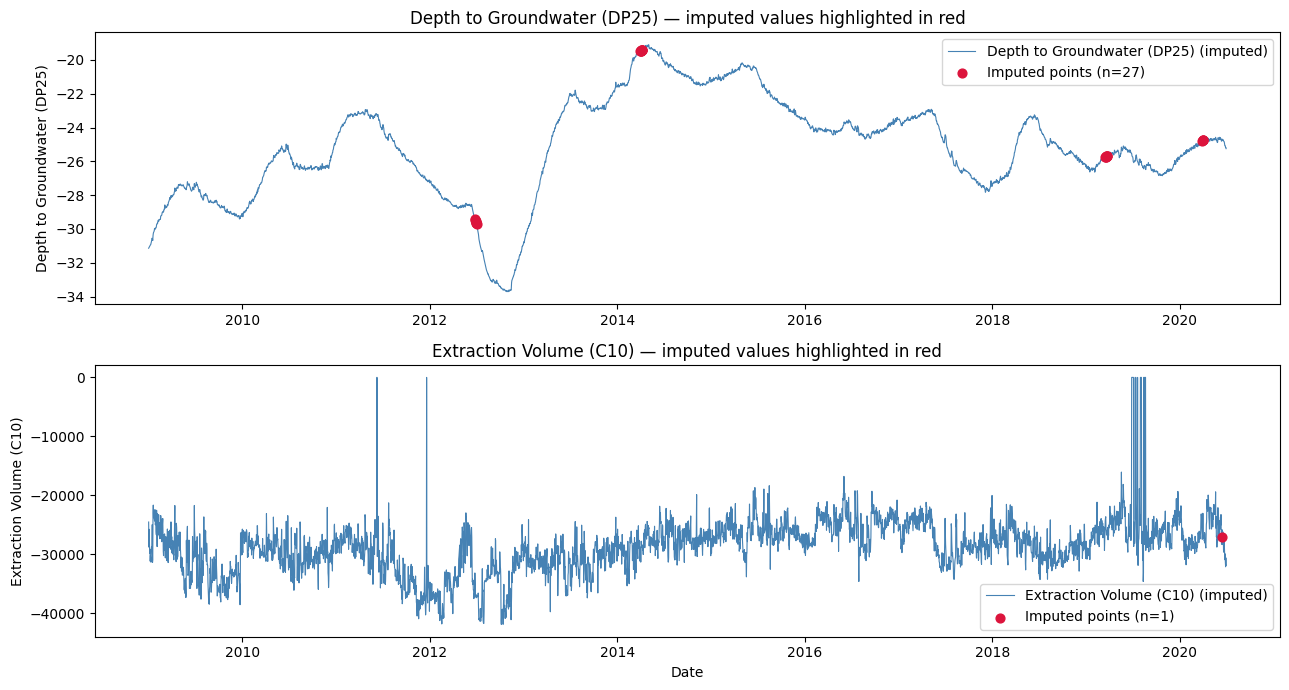

In [7]:
# --- Highlight imputed points on the time series ---

# Re-read raw CSV to recover original NaN positions
raw_df = pd.read_csv("petrignanos.csv")
raw_df["Date"] = pd.to_datetime(raw_df["Date"], dayfirst=True)
raw_df = raw_df.sort_values("Date").reset_index(drop=True)

targets = {
    "Depth_to_Groundwater_P25": "Depth to Groundwater (DP25)",
    "Volume_C10_Petrignano":    "Extraction Volume (C10)",
}

fig, axes = plt.subplots(len(targets), 1, figsize=(13, 7))

for ax, (col, label) in zip(axes, targets.items()):
    was_nan = raw_df[col].isna().values          # mask from raw file
    n_imputed = int(was_nan.sum())

    ax.plot(raw_df["Date"], df[col].values,
            color="steelblue", linewidth=0.8, label=f"{label} (imputed)")

    ax.scatter(raw_df["Date"][was_nan], df[col].values[was_nan],
               color="crimson", s=40, zorder=5,
               label=f"Imputed points (n={n_imputed})")

    ax.set_title(f"{label} — imputed values highlighted in red")
    ax.set_ylabel(label)
    ax.legend(loc="best")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

The data is resampled to monthly means because the monthly scale aligns with the physics, operations, and tasks. Physically, shallow alluvial aquifers respond to rainfall and evapotranspiration over weeks to months. Yang et al. (2025) report lags of 4.55 to 9.63 months and a 35.7% MAE reduction when such monthly lag effects are included. Operationally, ARPA Umbria has monitored the Valle Umbra Nord wells, including those near Petrignano and Assisi, on a monthly cadence since 1990 (Beretta et al., 2018).

In [8]:
# Resampling the data to monthly
agg_rules = {
    "Rainfall_Bastia_Umbra":                "sum",   # total mm per month
    "Depth_to_Groundwater_P25":             "mean",  # typical level
    "Temperature_Bastia_Umbra":             "mean",  # typical temperature
    "Temperature_Petrignano":               "mean",
    "Volume_C10_Petrignano":                "sum",   # total extraction per month
    "Hydrometry_Fiume_Chiascio_Petrignano": "mean",  # typical river level
}
df = df.set_index('Date') # Set 'Date' column as index
df_monthly = df[numeric_cols].resample("ME").agg(agg_rules)
df_monthly.head()

,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano
Date,,,,,,
2009-01-31,6.3,-30.503871,4.964516,4.945161,-827548.704,2.387097
2009-02-28,14.0,-29.350000,5.125000,4.792857,-717952.896,2.546429
2009-03-31,34.2,-28.502903,9.254839,8.716129,-879621.120,2.490323
2009-04-30,16.3,-27.736333,13.806667,13.250000,-845030.016,2.403333
2009-05-31,28.6,-27.478065,19.809677,18.812903,-997805.952,2.109677


In [9]:
# Simplify Column Names
df_monthly = df_monthly.rename(columns={
    "Rainfall_Bastia_Umbra":                "rainfall",
    "Depth_to_Groundwater_P25":             "depth_to_groundwater",
    "Temperature_Bastia_Umbra":             "temp_bastia",
    "Temperature_Petrignano":               "temp_petrignano",
    "Volume_C10_Petrignano":                "drainage_volume",
    "Hydrometry_Fiume_Chiascio_Petrignano": "river_hydrometry",
})

# Update the TARGET constant so the rest of the notebook still works
TARGET = "depth_to_groundwater"

df_monthly.head()

,rainfall,depth_to_groundwater,temp_bastia,temp_petrignano,drainage_volume,river_hydrometry
Date,,,,,,
2009-01-31,6.3,-30.503871,4.964516,4.945161,-827548.704,2.387097
2009-02-28,14.0,-29.350000,5.125000,4.792857,-717952.896,2.546429
2009-03-31,34.2,-28.502903,9.254839,8.716129,-879621.120,2.490323
2009-04-30,16.3,-27.736333,13.806667,13.250000,-845030.016,2.403333
2009-05-31,28.6,-27.478065,19.809677,18.812903,-997805.952,2.109677


Months can be represented in the machine learning model via cyclical encoding. Representing the calendar month as a raw integer (1–12) would mislead the model into treating December and January as maximally distant (11 units apart) when they are in fact adjacent points in the annual cycle, so we instead map each month onto the unit circle via `month_sin = sin(2π × month / 12)` and `month_cos = cos(2π × month / 12)`. Two features are needed rather than one because a lone sine is symmetric about its peak and cannot distinguish the rising half of the year from the falling half, whereas the sin/cos pair assigns every month a unique coordinate while preserving calendar proximity. This matters for Petrignano because groundwater depth follows a strong annual cycle, lowest in late summer and highest in spring, a rhythm documented for the Valle Umbra aquifer by Beretta et al. (2018) and consistent with Yang et al. (2025), who found that explicitly treating month as a predictor improves forecast accuracy.

In [10]:
# Add seasonality by performing cyclic encoding
df_monthly["month_sin"] = np.sin(2 * np.pi * df_monthly.index.month / 12)
df_monthly["month_cos"] = np.cos(2 * np.pi * df_monthly.index.month / 12)
df_monthly.head()

,rainfall,depth_to_groundwater,temp_bastia,temp_petrignano,drainage_volume,river_hydrometry,month_sin,month_cos
Date,,,,,,,,
2009-01-31,6.3,-30.503871,4.964516,4.945161,-827548.704,2.387097,0.500000,8.660254e-01
2009-02-28,14.0,-29.350000,5.125000,4.792857,-717952.896,2.546429,0.866025,5.000000e-01
2009-03-31,34.2,-28.502903,9.254839,8.716129,-879621.120,2.490323,1.000000,6.123234e-17
2009-04-30,16.3,-27.736333,13.806667,13.250000,-845030.016,2.403333,0.866025,-5.000000e-01
2009-05-31,28.6,-27.478065,19.809677,18.812903,-997805.952,2.109677,0.500000,-8.660254e-01


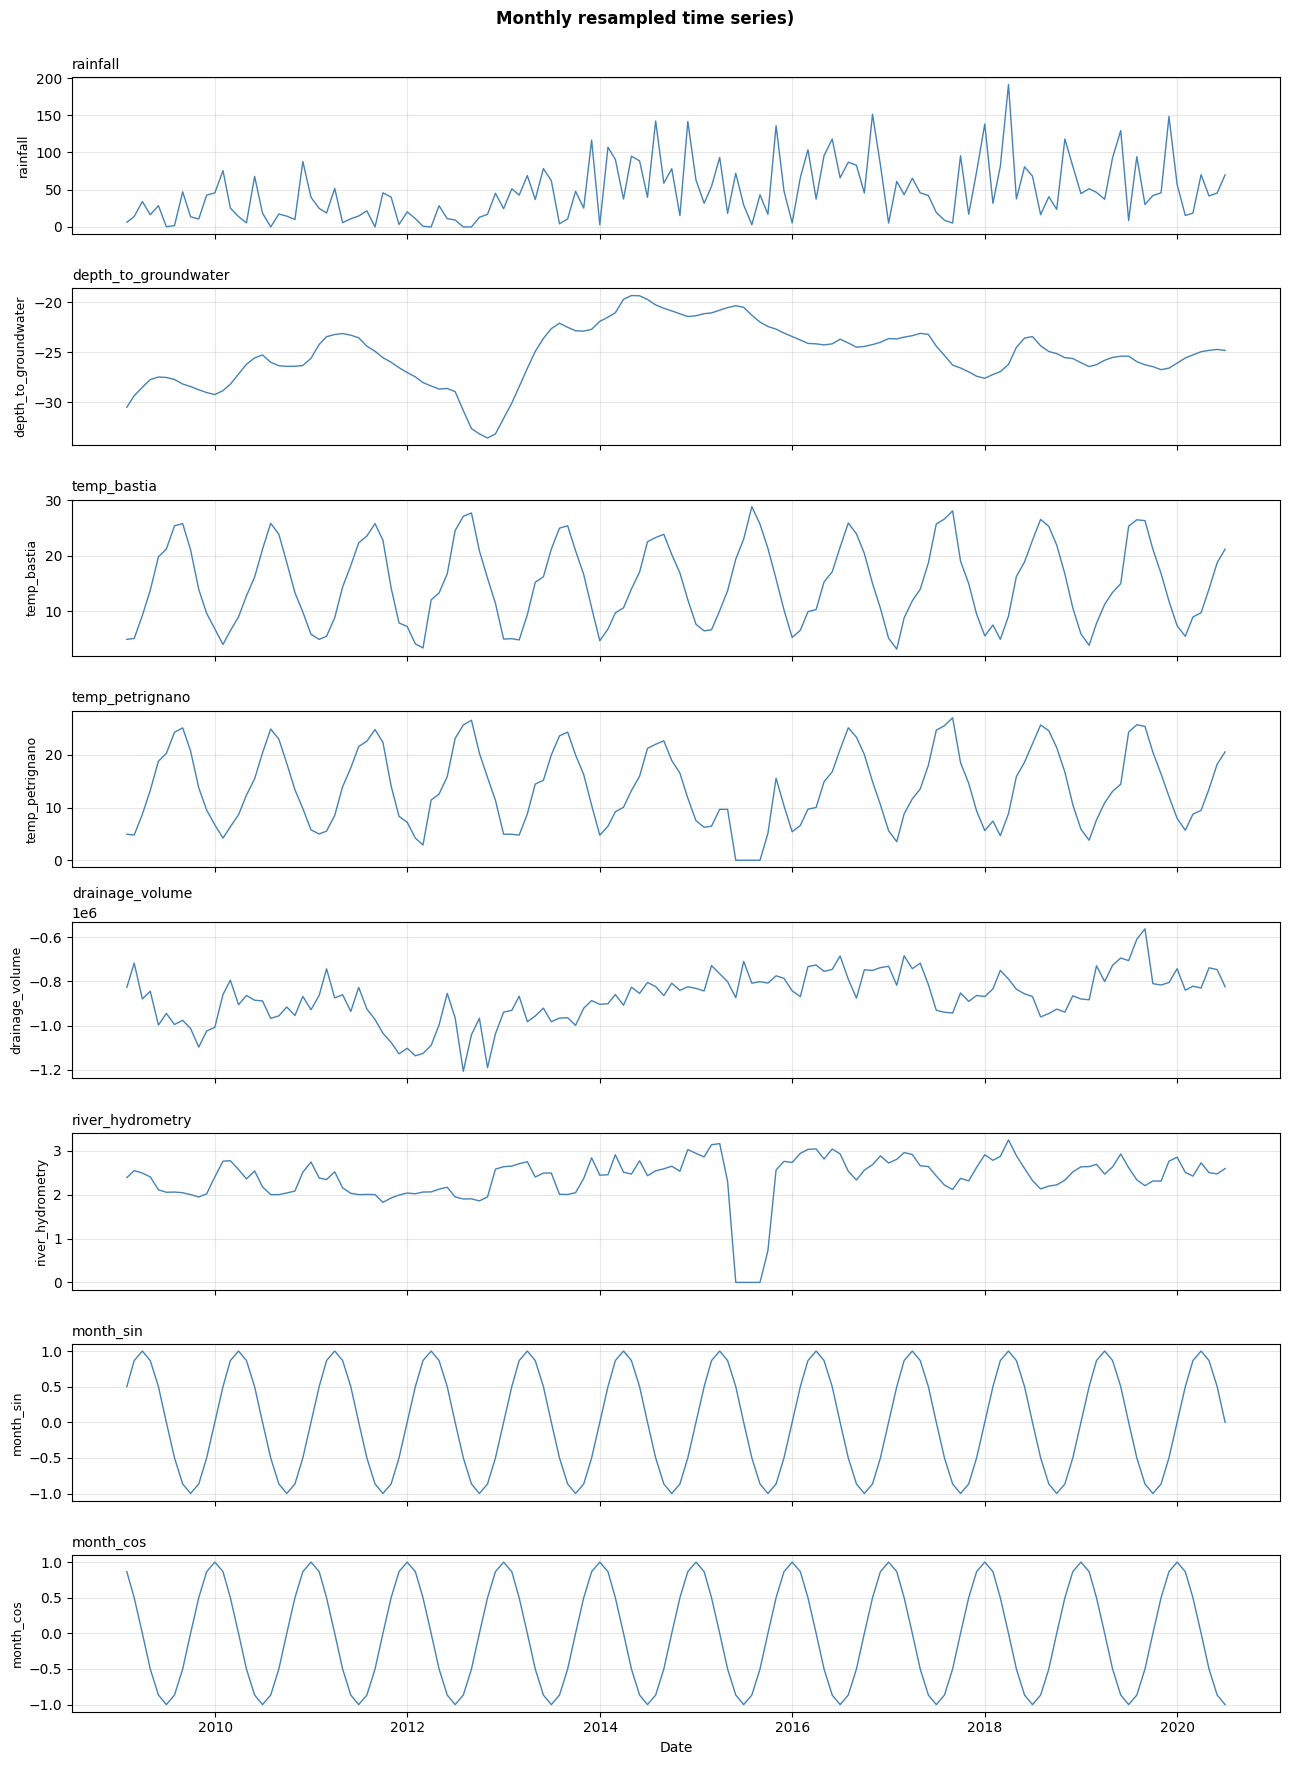

In [11]:
# Monthly time-series plots for each variable
fig, axes = plt.subplots(len(df_monthly.columns), 1,
                         figsize=(13, 2.2 * len(df_monthly.columns)),
                         sharex=True)

for ax, col in zip(axes, df_monthly.columns):
    ax.plot(df_monthly.index, df_monthly[col], linewidth=1.0, color="steelblue")
    ax.set_title(col, fontsize=10, loc="left")
    ax.set_ylabel(col, fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")
plt.suptitle("Monthly resampled time series)",
             fontsize=12, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

In [12]:
# Build lagged features: use all columns as predictors from months t-1 and t-2
TARGET = "depth_to_groundwater"
feature_cols = df_monthly.columns.tolist()

lagged_frames = []
for lag in [1, 2]:
    shifted = df_monthly[feature_cols].shift(lag)
    shifted.columns = [f"{col}_lag{lag}" for col in feature_cols]
    lagged_frames.append(shifted)

df_lagged = pd.concat(lagged_frames, axis=1)
df_lagged[TARGET] = df_monthly[TARGET]   # target at month t

# Drop rows with NaN introduced by lagging
df_lagged = df_lagged.dropna()

# Reorder so each variable's lag1 and lag2 are adjacent
ordered_cols = [f"{v}_lag{lag}" for v in feature_cols for lag in (1, 2)]
df_lagged = df_lagged[ordered_cols + [TARGET]]

# Define predictors (X) and response variable (y)
y = df_lagged[TARGET]
X = df_lagged.drop(columns=[TARGET])

print(f"Final dataset: {X.shape[0]} samples, {X.shape[1]} predictors")
print(f"Date range: {df_lagged.index.min()} to {df_lagged.index.max()}")
X.head()

Final dataset: 136 samples, 16 predictors
Date range: 2009-03-31 00:00:00 to 2020-06-30 00:00:00


,rainfall_lag1,rainfall_lag2,depth_to_groundwater_lag1,depth_to_groundwater_lag2,temp_bastia_lag1,temp_bastia_lag2,temp_petrignano_lag1,temp_petrignano_lag2,drainage_volume_lag1,drainage_volume_lag2,river_hydrometry_lag1,river_hydrometry_lag2,month_sin_lag1,month_sin_lag2,month_cos_lag1,month_cos_lag2
Date,,,,,,,,,,,,,,,,
2009-03-31,14.0,6.3,-29.350000,-30.503871,5.125000,4.964516,4.792857,4.945161,-717952.896,-827548.704,2.546429,2.387097,8.660254e-01,0.500000,5.000000e-01,8.660254e-01
2009-04-30,34.2,14.0,-28.502903,-29.350000,9.254839,5.125000,8.716129,4.792857,-879621.120,-717952.896,2.490323,2.546429,1.000000e+00,0.866025,6.123234e-17,5.000000e-01
2009-05-31,16.3,34.2,-27.736333,-28.502903,13.806667,9.254839,13.250000,8.716129,-845030.016,-879621.120,2.403333,2.490323,8.660254e-01,1.000000,-5.000000e-01,6.123234e-17
2009-06-30,28.6,16.3,-27.478065,-27.736333,19.809677,13.806667,18.812903,13.250000,-997805.952,-845030.016,2.109677,2.403333,5.000000e-01,0.866025,-8.660254e-01,-5.000000e-01
2009-07-31,0.3,28.6,-27.522000,-27.478065,21.203333,19.809677,20.273333,18.812903,-945444.960,-997805.952,2.053333,2.109677,1.224647e-16,0.500000,-1.000000e+00,-8.660254e-01


# 1. THE HARD SPLIT
Split the data chronologically (no shuffling) into 80% training and 20% test. The test set represents the most recent "future" months, serving as an **independent test data set**.

In [13]:
# Ensure X and y are pre-sorted chronologically!
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

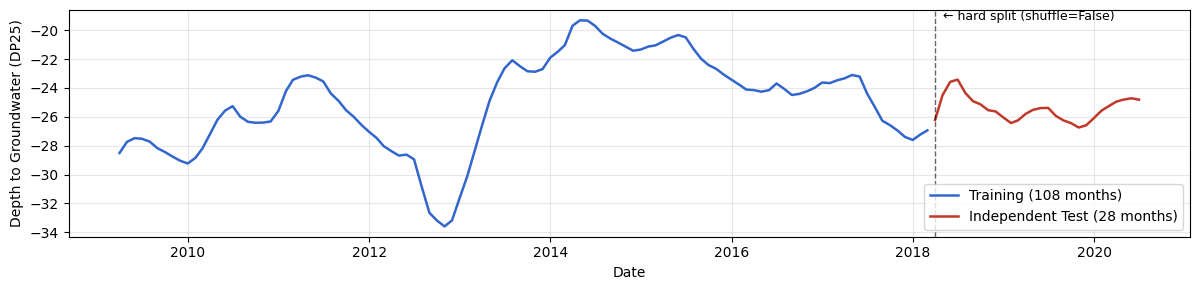

Training window:  2009-03-31 → 2018-02-28
Test window:      2018-03-31 → 2020-06-30


In [25]:
# @markdown **Prompt:** Help me visualize this train-test split by creating a time-series graph where validation and test. Add a vertical line to indicate where the hard split is.
# --- Visualise the hard train/test split on the DP25 time series ---
fig, ax = plt.subplots(figsize=(12.1, 3))

# Training portion in blue
ax.plot(y_train_full.index, y_train_full.values,
        color="#3366CC", linewidth=1.8, label=f"Training ({len(y_train_full)} months)")

# Test portion in red
ax.plot(y_test.index, y_test.values,
        color="#C0392B", linewidth=1.8, label=f"Independent Test ({len(y_test)} months)")

# Vertical marker showing the split boundary
split_date = y_test.index.min()
ax.axvline(split_date, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.text(split_date, ax.get_ylim()[1], "  ← hard split (shuffle=False)",
        fontsize=9, va="top", ha="left")

ax.set_xlabel("Date")
ax.set_ylabel("Depth to Groundwater (DP25)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Training window:  {y_train_full.index.min().date()} → {y_train_full.index.max().date()}")
print(f"Test window:      {y_test.index.min().date()} → {y_test.index.max().date()}")

# 2. DEFINE THE TWO CV STRATEGIES

- **KFold (Naive):** Shuffles data across **folds**, ignoring temporal order.
- **TimeSeriesSplit (Temporal):** Respects chronological order. Each fold uses only past data for training and the next time block for validation.

In [15]:
cv_naive = KFold(n_splits=5, shuffle=True, random_state=42)
cv_temporal = TimeSeriesSplit(n_splits=5)

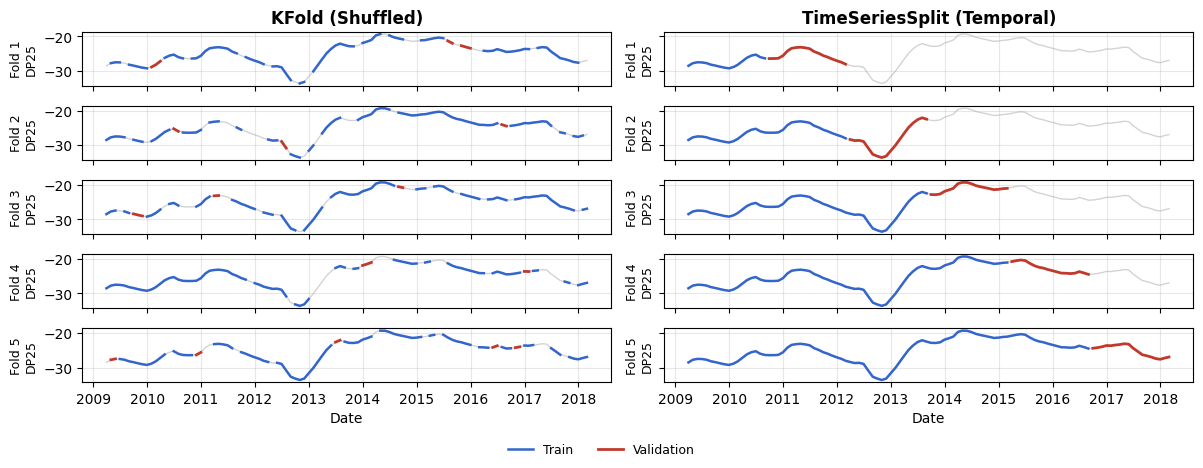

In [24]:
# @markdown **Prompt:** Help me visualize this train-test split by creating a time-series graph where validation and test. Add a vertical line to indicate where the hard split is.
import matplotlib.dates as mdates

strategies = [
    (KFold(n_splits=5, shuffle=True, random_state=42), "KFold (Shuffled)"),
    (TimeSeriesSplit(n_splits=5),                        "TimeSeriesSplit (Temporal)"),
]

n_folds  = 5
dates    = y_train_full.index
y_values = y_train_full.values

fig, axes = plt.subplots(n_folds, 2, figsize=(12.13, 4.7), sharex=True, sharey=True)

for col, (cv, strategy_name) in enumerate(strategies):
    for fold_i, (train_idx, val_idx) in enumerate(cv.split(y_train_full)):
        ax = axes[fold_i, col]

        train_line = np.full_like(y_values, np.nan, dtype=float)
        val_line   = np.full_like(y_values, np.nan, dtype=float)
        train_line[train_idx] = y_values[train_idx]
        val_line[val_idx]     = y_values[val_idx]

        ax.plot(dates, y_values, color="lightgrey", linewidth=1, zorder=1)
        train_plot, = ax.plot(dates, train_line, color="#3366CC", linewidth=1.8, zorder=2)
        val_plot,   = ax.plot(dates, val_line,   color="#C0392B", linewidth=2.0, zorder=3)

        ax.set_ylabel(f"Fold {fold_i + 1}\nDP25", fontsize=9)
        ax.grid(alpha=0.3)

        if fold_i == 0:
            ax.set_title(strategy_name, fontsize=12, fontweight="bold")

# Shared legend (bottom center)
fig.legend(
    [train_plot, val_plot],
    ["Train", "Validation"],
    loc="lower center",
    ncol=2,
    fontsize=9,
    frameon=False
)

axes[-1, 0].set_xlabel("Date")
axes[-1, 1].set_xlabel("Date")
axes[-1, 0].xaxis.set_major_locator(mdates.YearLocator())
axes[-1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Leave space for legend at bottom
plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()

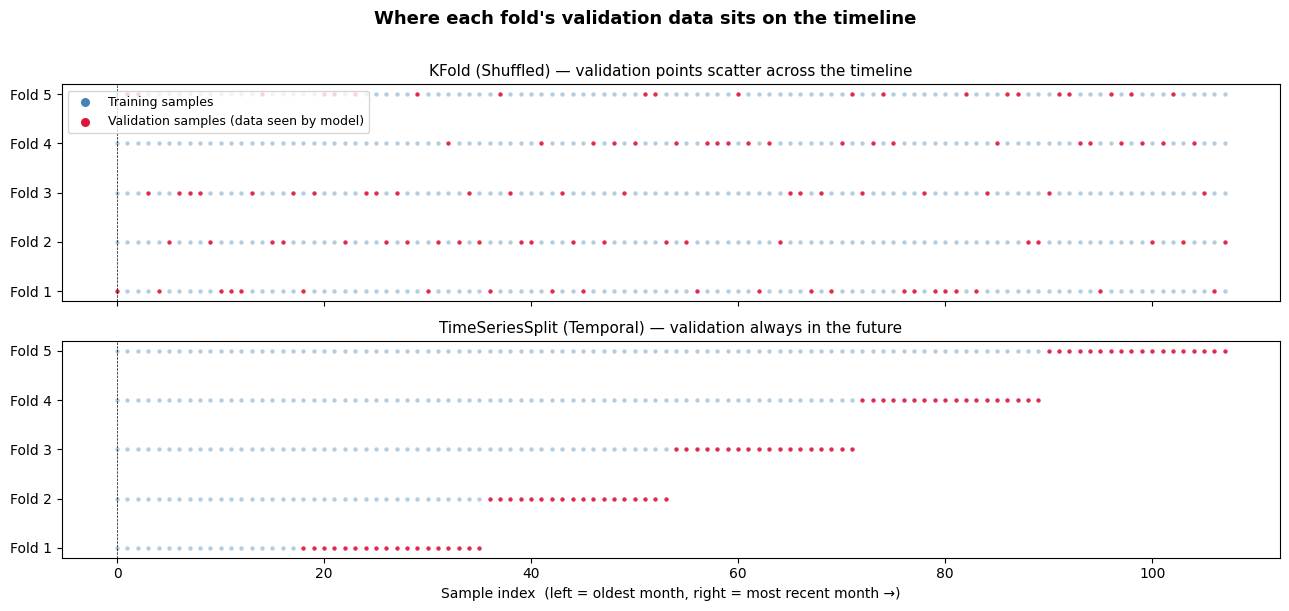

In [17]:
# @markdown **Prompt:** Help me generate another visualization to display train-validation split for both CV approaches.
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

strategies = [
    (KFold(n_splits=5, shuffle=True, random_state=42), "KFold (Shuffled) — validation points scatter across the timeline"),
    (TimeSeriesSplit(n_splits=5),                        "TimeSeriesSplit (Temporal) — validation always in the future"),
]
colors = {"train": "steelblue", "val": "crimson"}

for ax, (cv, title) in zip(axes, strategies):
    for fold_i, (train_idx, val_idx) in enumerate(cv.split(X_train_full)):
        ax.scatter(train_idx, [fold_i] * len(train_idx),
                   c=colors["train"], s=10, alpha=0.4, linewidths=0)
        ax.scatter(val_idx,   [fold_i] * len(val_idx),
                   c=colors["val"],   s=10, alpha=0.9, linewidths=0)
    ax.set_yticks(range(5))
    ax.set_yticklabels([f"Fold {i+1}" for i in range(5)])
    ax.set_title(title, fontsize=11)
    ax.axvline(0, color="k", linewidth=0.5, linestyle="--")

axes[1].set_xlabel("Sample index  (left = oldest month, right = most recent month →)", fontsize=10)

legend_elements = [
    plt.scatter([], [], c=colors["train"], s=30, label="Training samples"),
    plt.scatter([], [], c=colors["val"],   s=30, label="Validation samples (data seen by model)"),
]
axes[0].legend(handles=legend_elements, loc="upper left", fontsize=9)

plt.suptitle("Where each fold's validation data sits on the timeline", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


# 3. EXPERIMENT WITH A FIXED MODEL

In [18]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', DecisionTreeRegressor(max_depth=10, random_state=42))
])

# Strategy 1: Naive (Shuffled)
# This will likely report a very high R2 because of leakage.
scores_naive = cross_val_score(pipe, X_train_full, y_train_full, cv=cv_naive, scoring='r2')

# Strategy 2: Temporal (Sequential)
# This will report a lower, more honest R2.
scores_temporal = cross_val_score(pipe, X_train_full, y_train_full, cv=cv_temporal, scoring='r2')

print(f"Naive CV R2:    {scores_naive.mean():.4f} (+/- {scores_naive.std():.4f})")
print(f"Temporal CV R2: {scores_temporal.mean():.4f} (+/- {scores_temporal.std():.4f})")

# Train on all training data and test on the unseen "future"
pipe.fit(X_train_full, y_train_full)
final_test_r2 = r2_score(y_test, pipe.predict(X_test))

print(f"\nActual Test R2 on Independent Test Set: {final_test_r2:.4f}")

Naive CV R2:    0.9090 (+/- 0.0380)
Temporal CV R2: -0.7158 (+/- 2.2354)

Actual Test R2 on Independent Test Set: -0.2702


# 4. MODEL SELECTION & EVALUATION

Use `GridSearchCV` to perform **model selection** by tuning **hyperparameters** (`max_depth` of the Decision Tree). The function is called once with each CV strategy to compare how each estimates generalization performance.

In [19]:
def evaluate_model_selection(X_train, y_train, X_test, y_test, cv_strategy, name):
    """
    Performs model selection via GridSearchCV with the given CV strategy,
    then evaluates on the independent test set.
    """

    # STEP A: Define the Pipeline
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", DecisionTreeRegressor(random_state=42)),
    ])

    # STEP B: Define the Hyperparameter Grid
    param_grid = {
        "regressor__max_depth": [3, 5, 10, 15, 20, None],
    }

    # STEP C: Initialize and Fit GridSearchCV
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv_strategy,
        scoring="r2",
        n_jobs=-1,
    )

    grid.fit(X_train, y_train)

     # STEP D: Final Evaluation
    # Use the 'best_estimator_' to predict the unseen X_test
    y_pred = grid.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)

    print(f"\n===== Results for: {name} =====")
    print(f"Best Parameters found: {grid.best_params_}")
    print(f"Internal CV Score (R2): {grid.best_score_:.4f}")
    print(f"Independent Test Score (R2): {test_r2:.4f}")

    return grid

# 5. RUNNING THE COMPARISON

Call `evaluate_model_selection` with both CV strategies and compare:
- **(A)** Independent Test Score
- **(B)** KFold Internal CV Score
- **(C)** TimeSeriesSplit Internal CV Score

In [20]:

# Call the function twice and compare the gaps between CV and Test scores.

result_naive = evaluate_model_selection(X_train_full, y_train_full, X_test, y_test, cv_naive, "Naive K-Fold")
result_temporal = evaluate_model_selection(X_train_full, y_train_full, X_test, y_test, cv_temporal, "Temporal Split")


===== Results for: Naive K-Fold =====
Best Parameters found: {'regressor__max_depth': 5}
Internal CV Score (R2): 0.9102
Independent Test Score (R2): -0.3183

===== Results for: Temporal Split =====
Best Parameters found: {'regressor__max_depth': 3}
Internal CV Score (R2): 0.1339
Independent Test Score (R2): 0.3118


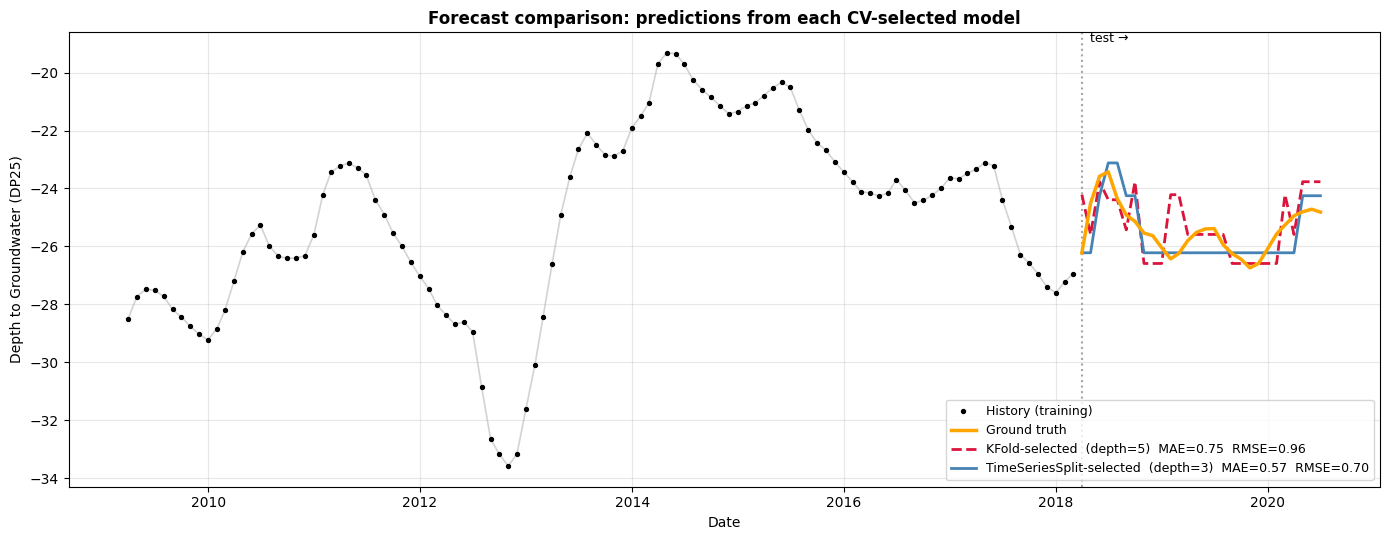

KFold-selected model         (max_depth=5):  MAE=0.746  RMSE=0.963
TimeSeriesSplit-selected model (max_depth=3):  MAE=0.570  RMSE=0.696


In [21]:
# @markdown **Prompt:** Create a forecast visualization comparing both CV-strategies selected.
# --- Forecast visualisation comparing both CV-selected models ---
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_kfold   = result_naive.predict(X_test)
y_pred_tssplit = result_temporal.predict(X_test)

mae_k, rmse_k = (mean_absolute_error(y_test, y_pred_kfold),
                 np.sqrt(mean_squared_error(y_test, y_pred_kfold)))
mae_t, rmse_t = (mean_absolute_error(y_test, y_pred_tssplit),
                 np.sqrt(mean_squared_error(y_test, y_pred_tssplit)))

best_k = result_naive.best_params_["regressor__max_depth"]
best_t = result_temporal.best_params_["regressor__max_depth"]

fig, ax = plt.subplots(figsize=(14, 5.5))

# Grey line overlay connecting the historical points
ax.plot(y_train_full.index, y_train_full.values,
        color="lightgrey", linewidth=1.2, zorder=1)

# Historical training data as black dots on top
ax.scatter(y_train_full.index, y_train_full.values,
           color="black", s=8, zorder=2, label="History (training)")

# Ground truth on the test window
ax.plot(y_test.index, y_test.values,
        color="orange", linewidth=2.5, label="Ground truth", zorder=5)

# KFold-selected prediction
ax.plot(y_test.index, y_pred_kfold,
        color="crimson", linewidth=2, linestyle="--", zorder=4,
        label=f"KFold-selected  (depth={best_k})  MAE={mae_k:.2f}  RMSE={rmse_k:.2f}")

# TimeSeriesSplit-selected prediction
ax.plot(y_test.index, y_pred_tssplit,
        color="steelblue", linewidth=2, zorder=4,
        label=f"TimeSeriesSplit-selected  (depth={best_t})  MAE={mae_t:.2f}  RMSE={rmse_t:.2f}")

# Split marker
ax.axvline(y_test.index.min(), color="grey", linestyle=":", alpha=0.7)
ax.text(y_test.index.min(), ax.get_ylim()[1], "  test →",
        fontsize=9, va="top", ha="left")

ax.set_title("Forecast comparison: predictions from each CV-selected model",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Depth to Groundwater (DP25)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"KFold-selected model         (max_depth={best_k}):  MAE={mae_k:.3f}  RMSE={rmse_k:.3f}")
print(f"TimeSeriesSplit-selected model (max_depth={best_t}):  MAE={mae_t:.3f}  RMSE={rmse_t:.3f}")

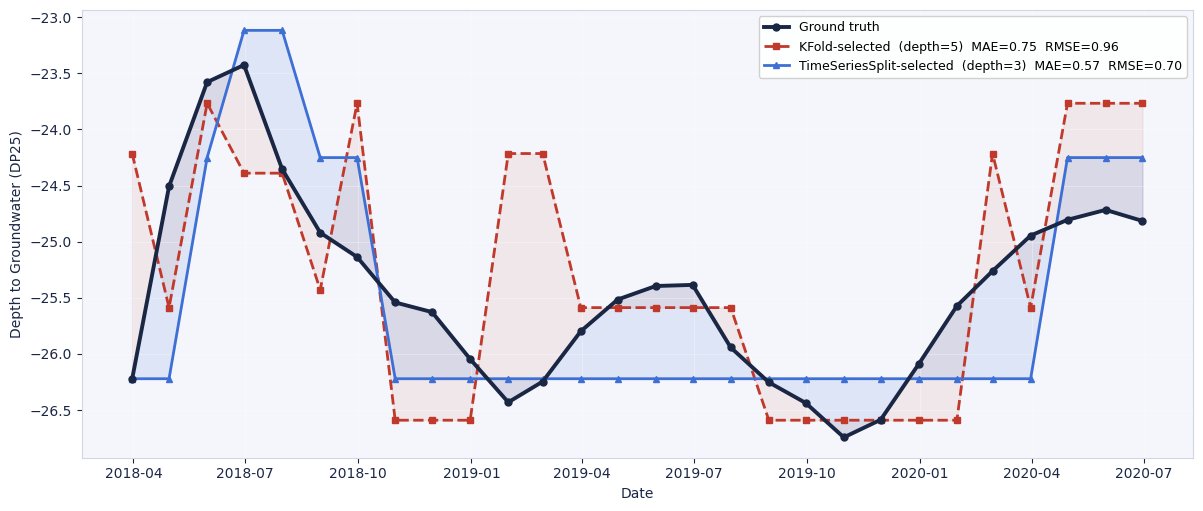

KFold-selected         (depth=5):  MAE=0.746  RMSE=0.963
TimeSeriesSplit-selected (depth=3):  MAE=0.570  RMSE=0.696


In [22]:
# @markdown **Prompt:** Now create a zoomed-in version visualizing only the test

# ── Colour palette aligned with slide ──────────────────────────
NAVY      = "#1a2744"   # dark navy  → ground truth (matches test line)
BLUE      = "#3d6fd4"   # bright blue → TimeSeriesSplit (matches training line)
RED       = "#c0392b"   # muted red  → KFold (contrast / warning colour)
LIGHT_BG  = "#f4f6fb"   # slide background tint

# --- Zoomed forecast comparison: test window only ---
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_kfold   = result_naive.predict(X_test)
y_pred_tssplit = result_temporal.predict(X_test)

mae_k, rmse_k = (mean_absolute_error(y_test, y_pred_kfold),
                 np.sqrt(mean_squared_error(y_test, y_pred_kfold)))
mae_t, rmse_t = (mean_absolute_error(y_test, y_pred_tssplit),
                 np.sqrt(mean_squared_error(y_test, y_pred_tssplit)))

best_k = result_naive.best_params_["regressor__max_depth"]
best_t = result_temporal.best_params_["regressor__max_depth"]

fig, ax = plt.subplots(figsize=(12.13, 5.21), facecolor="white")
ax.set_facecolor(LIGHT_BG)

# Ground truth
ax.plot(y_test.index, y_test.values,
        color=NAVY, linewidth=2.8, marker="o", markersize=5,
        label="Ground truth", zorder=5)

# KFold-selected prediction
ax.plot(y_test.index, y_pred_kfold,
        color=RED, linewidth=2, linestyle="--",
        marker="s", markersize=5, zorder=4,
        label=f"KFold-selected  (depth={best_k})  MAE={mae_k:.2f}  RMSE={rmse_k:.2f}")

# TimeSeriesSplit-selected prediction
ax.plot(y_test.index, y_pred_tssplit,
        color=BLUE, linewidth=2,
        marker="^", markersize=5, zorder=4,
        label=f"TimeSeriesSplit-selected  (depth={best_t})  MAE={mae_t:.2f}  RMSE={rmse_t:.2f}")

# Shaded error regions
ax.fill_between(y_test.index, y_test.values, y_pred_kfold,
                color=RED, alpha=0.08)
ax.fill_between(y_test.index, y_test.values, y_pred_tssplit,
                color=BLUE, alpha=0.12)
ax.set_xlabel("Date", color=NAVY)
ax.set_ylabel("Depth to Groundwater (DP25)", color=NAVY)
ax.tick_params(colors=NAVY)
for spine in ax.spines.values():
    spine.set_edgecolor("#d0d7e8")
ax.grid(alpha=0.3, color="white")
ax.legend(loc="best", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

print(f"KFold-selected         (depth={best_k}):  MAE={mae_k:.3f}  RMSE={rmse_k:.3f}")
print(f"TimeSeriesSplit-selected (depth={best_t}):  MAE={mae_t:.3f}  RMSE={rmse_t:.3f}")

## Discussion

**Key observations:**

1. **Naive K-Fold CV R2 (B)** is significantly higher than the **Independent Test R2 (A)**. This gap reveals **data leakage**: by shuffling time-series data, future observations leak into training folds, making the model appear more accurate than it truly is.

2. **TimeSeriesSplit CV R2 (C)** is lower than the Naive K-Fold score but much closer to the **Independent Test R2 (A)**. This confirms that temporal cross-validation provides a more honest and realistic estimate of how the model will perform on unseen future data.

3. The **Independent Test R2 (A)** serves as the ground truth — it measures performance on data the model has never seen during training or model selection. The fact that TimeSeriesSplit's internal estimate is closer to this value shows it is the appropriate cross-validation strategy for time-series problems.

4. The model chosen by TimeSeriesSplit (depth=3, MAE=0.57) follows the real ups and downs of groundwater depth much better than the KFold model (depth=5, MAE=0.75), which is erratic and jumps around with short-term changes.

**Conclusion:** For time-series forecasting, always use `TimeSeriesSplit` (or similar temporal strategies) instead of shuffled `KFold` to avoid optimistic bias from data leakage during model selection and hyperparameter tuning.

## References Used

- Beretta, G. P., Avanzini, M., Marangoni, T., Burini, M., Schirò, G.,
    Terrenghi, J., & Vacca, G. (2018). Groundwater modeling of the
    withdrawal sustainability of Cannara artesian aquifer (Umbria, Italy).
    Acque Sotterranee — Italian Journal of Groundwater, 7(3), 47–60.
    https://doi.org/10.7343/as-2018-333
- Noor, M. N., Yahaya, A. S., Ramli, N. A., & Mustafa Al Bakri, A. M. (2014). Filling missing data using interpolation methods: Study on the effect of fitting distribution. Key Engineering Materials, 594–595, 889–895. https://doi.org/10.4028/www.scientific.net/KEM.594-595.889
- [pandas.DataFrame.interpolate](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html)
- [pandas.DataFrame.resample](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html)
- Yang, F., Zhang, X., Yang, J., Zhang, J., Dai, Q., & Zhu, S. (2025).
    Enhancing groundwater predictions by incorporating response lag
    effects in machine learning models. Journal of Hydroinformatics,
    27(2), 338–356. https://doi.org/10.2166/hydro.2025.295